In [1]:
import pandas as pd

data = {
    "income": [30000, 50000, 120000, 20000],
    "loan": [200000, 100000, 50000, 150000],
    "default": [1, 0, 0, 1]
}

df = pd.DataFrame(data)
df

,income,loan,default
0,30000,200000,1
1,50000,100000,0
2,120000,50000,0
3,20000,150000,1


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(url)

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee/official,1,yes,yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,no,yes,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,no,yes,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,building society savings agreement/life insurance,45,none,for free,1,skilled employee/official,2,no,yes,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,no,yes,0


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  number_credits  

In [5]:
df['credit_risk'].value_counts()

credit_risk
1    700
0    300
Name: count, dtype: int64

In [6]:
df['credit_risk'].mean()

np.float64(0.7)

In [9]:
df.groupby('credit_risk')['amount'].mean()

credit_risk
0    3938.126667
1    2985.457143
Name: amount, dtype: float64

In [11]:
df.groupby('credit_risk')['age'].mean()

credit_risk
0    33.963333
1    36.224286
Name: age, dtype: float64

In [12]:
df.groupby('credit_risk')['duration'].mean()

credit_risk
0    24.860000
1    19.207143
Name: duration, dtype: float64

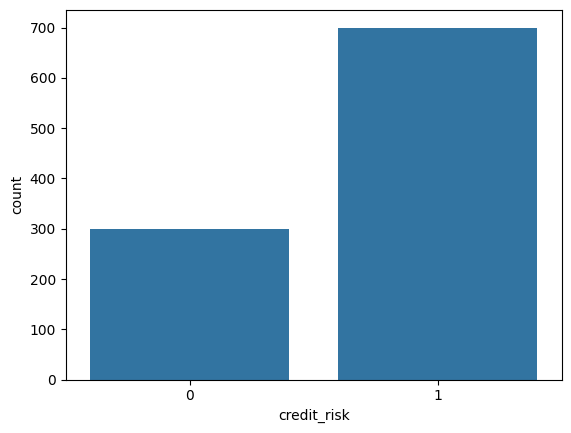

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='credit_risk', data=df)
plt.show()

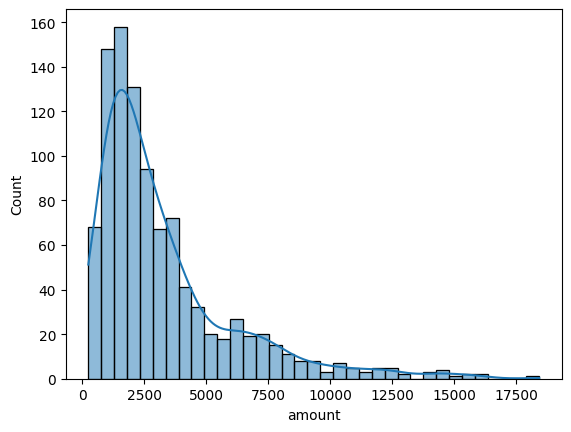

In [15]:
sns.histplot(df['amount'], kde=True)
plt.show()

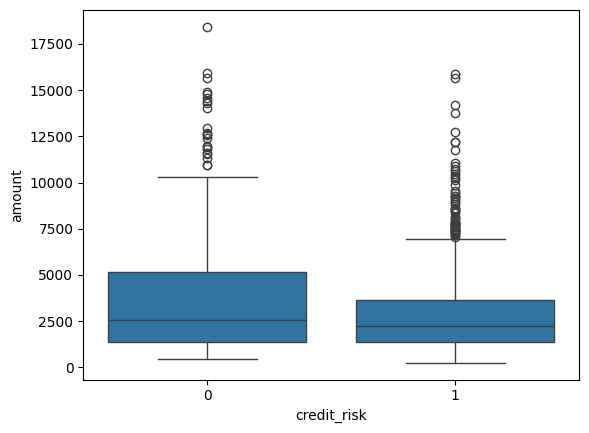

In [16]:
sns.boxplot(x='credit_risk', y='amount', data=df)
plt.show()

In [17]:
df['credit_risk'].dtype

dtype('int64')

In [18]:
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

In [19]:
X = pd.get_dummies(X, drop_first=True)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
print(model.score(X_test, y_test))

0.785


In [24]:
y_pred = model.predict(X_test)

In [25]:
print(X_train.shape)
print(X_test.shape)

(800, 48)
(200, 48)


In [26]:
print("Training complete")

Training complete


In [30]:
model.fit(X_train, y_train)

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
print(model)

LogisticRegression(max_iter=1000)


In [32]:
print("Training completed")

Training completed


In [33]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[1 0 0 1 1 1 1 1 1 1]


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [35]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
y_pred = model.predict(X_test_scaled)

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.805


In [39]:
print(X_train.shape)

(800, 48)


In [40]:
print(X_train.shape)

(800, 48)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [43]:
print("Training complete")

Training complete


In [44]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

[1 0 0 1 1 1 1 0 1 1]


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.805


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 35  24]
 [ 15 126]]


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.59      0.64        59
           1       0.84      0.89      0.87       141

    accuracy                           0.81       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.80      0.81      0.80       200



In [48]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8177665584805865


In [52]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
).head(15)

,Feature,Coefficient
9,status_no checking account,0.779592
10,credit_history_critical account/other credits ...,0.614802
4,age,0.322607
39,other_installment_plans_none,0.290778
26,savings_unknown/no savings account,0.266388
11,credit_history_delay in paying off in the past,0.264661
12,credit_history_existing credits paid back duly...,0.254010
33,personal_status_sex_male : single,0.253371
7,status_... >= 200 DM / salary for at least 1 year,0.251524
34,other_debtors_guarantor,0.216719


In [53]:
from sklearn.tree import DecisionTreeClassifier

In [54]:
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [55]:
y_pred_tree = tree.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score

accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.73


In [57]:
from sklearn.metrics import roc_auc_score

y_prob_tree = tree.predict_proba(X_test)[:, 1]

auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

print("Decision Tree ROC-AUC:", auc_tree)

Decision Tree ROC-AUC: 0.7622310373843011


In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
y_pred_rf = rf.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.77


In [64]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.766558480586609


In [65]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
1,amount,0.119871
4,age,0.091788
0,duration,0.083414
9,status_no checking account,0.063666
2,installment_rate,0.045359
3,present_residence,0.039245
14,purpose_car (new),0.023899
10,credit_history_critical account/other credits ...,0.023076
5,number_credits,0.021291
41,housing_own,0.020795


In [66]:
print(df.columns.tolist())

['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']


In [67]:
Age = 23

In [70]:
df['young_customer'] = (df['age'] < 25).astype(int)

In [71]:
df['long_term_loan'] = (df['duration'] > 36).astype(int)

In [72]:
CreditAmount = 15,000

In [73]:
df['large_loan'] = (df['amount'] > 10000).astype(int)

In [74]:
df['age_band'] = pd.cut(
    df['age'],
    bins=[18,25,35,50,100],
    labels=['18-25','26-35','36-50','50+']
)

In [75]:
df['credit_duration_interaction'] = (
    df['amount'] * df['duration']
)

In [76]:
print(df.columns.tolist())

['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk', 'young_customer', 'long_term_loan', 'large_loan', 'age_band', 'credit_duration_interaction']


In [77]:
df['amount_per_month'] = df['amount'] / df['duration']

In [78]:
df['credit_burden'] = df['amount'] * df['number_credits']

In [79]:
df['senior_customer'] = (df['age'] >= 50).astype(int)

In [80]:
df['high_installment'] = (df['installment_rate'] >= 4).astype(int)

In [81]:
df['large_long_loan'] = (
    df['large_loan'] *
    df['long_term_loan']
)

In [82]:
df.groupby('large_long_loan')['credit_risk'].mean()

large_long_loan
0    0.704499
1    0.500000
Name: credit_risk, dtype: float64

In [83]:
df.groupby('young_customer')['credit_risk'].mean()

young_customer
0    0.719154
1    0.590604
Name: credit_risk, dtype: float64

In [84]:
df.groupby('senior_customer')['credit_risk'].mean()

senior_customer
0    0.696
1    0.728
Name: credit_risk, dtype: float64

In [85]:
df.groupby('high_installment')['credit_risk'].mean()

high_installment
0    0.730916
1    0.665966
Name: credit_risk, dtype: float64

In [86]:
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

In [87]:
X = pd.get_dummies(X, drop_first=True)

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [91]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.806467123452338


In [92]:
y_pred = model.predict(X_test_scaled)

In [93]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.785


In [94]:
df.groupby('high_installment')['credit_risk'].agg(['count','mean'])

,count,mean
high_installment,,
0,524,0.730916
1,476,0.665966


In [95]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
).head(15)

,Feature,Coefficient
18,status_no checking account,0.773010
19,credit_history_critical account/other credits ...,0.624150
58,age_band_36-50,0.399232
57,age_band_26-35,0.379936
15,large_long_loan,0.321568
48,other_installment_plans_none,0.316821
59,age_band_50+,0.291983
4,age,0.280176
35,savings_unknown/no savings account,0.278740
21,credit_history_existing credits paid back duly...,0.277987


In [96]:
coefficients.sort_values(
    by='Coefficient',
    ascending=True
).head(15)

,Feature,Coefficient
23,purpose_car (new),-0.561685
0,duration,-0.464499
31,purpose_retraining,-0.340224
2,installment_rate,-0.318523
9,large_loan,-0.294481
56,foreign_worker_yes,-0.203405
51,housing_rent,-0.190561
11,amount_per_month,-0.189719
28,purpose_others,-0.188055
13,senior_customer,-0.158969


In [97]:
corr = df.select_dtypes(include='number').corr()

corr['credit_risk'].sort_values(
    ascending=False
)

credit_risk                    1.000000
age                            0.091127
number_credits                 0.045732
senior_customer                0.023094
people_liable                  0.003015
present_residence             -0.002967
amount_per_month              -0.018592
large_long_loan               -0.065458
high_installment              -0.070784
installment_rate              -0.072404
young_customer                -0.099890
credit_burden                 -0.123855
large_loan                    -0.133631
long_term_loan                -0.146338
amount                        -0.154739
credit_duration_interaction   -0.171671
duration                      -0.214927
Name: credit_risk, dtype: float64

In [98]:
model.coef_[0]

array([-0.46449937, -0.13573116, -0.31852276, -0.01003399,  0.28017561,
       -0.15647521, -0.08396576,  0.15022421, -0.09264235, -0.29448142,
        0.1706055 , -0.18971887, -0.10383647, -0.15896888, -0.04510383,
        0.32156826,  0.25098857,  0.21128262,  0.77300958,  0.6241498 ,
        0.24788795,  0.27798725, -0.06885868, -0.56168504,  0.11601508,
       -0.13801554, -0.12937034, -0.00556246, -0.18805534, -0.11424972,
       -0.09537232, -0.34022419,  0.1836442 ,  0.02883995,  0.07433799,
        0.27873965,  0.1003452 ,  0.01066357,  0.17725879, -0.02738687,
       -0.1142459 , -0.02362813,  0.23232511,  0.22502236,  0.03199855,
        0.04476184,  0.14490866, -0.10604816,  0.31682059,  0.05647634,
        0.02974248, -0.19056109,  0.0080847 ,  0.17718388,  0.05381214,
        0.11106382, -0.20340493,  0.37993636,  0.39923188,  0.29198304])

In [99]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.head())

             Feature  Coefficient
0           duration    -0.464499
1             amount    -0.135731
2   installment_rate    -0.318523
3  present_residence    -0.010034
4                age     0.280176


In [100]:
positive_features = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(positive_features.head(10))

                                              Feature  Coefficient
18                         status_no checking account     0.773010
19  credit_history_critical account/other credits ...     0.624150
58                                     age_band_36-50     0.399232
57                                     age_band_26-35     0.379936
15                                    large_long_loan     0.321568
48                       other_installment_plans_none     0.316821
59                                       age_band_50+     0.291983
4                                                 age     0.280176
35                 savings_unknown/no savings account     0.278740
21  credit_history_existing credits paid back duly...     0.277987


In [101]:
negative_features = coefficients.sort_values(
    by="Coefficient",
    ascending=True
)

print(negative_features.head(10))

               Feature  Coefficient
23   purpose_car (new)    -0.561685
0             duration    -0.464499
31  purpose_retraining    -0.340224
2     installment_rate    -0.318523
9           large_loan    -0.294481
56  foreign_worker_yes    -0.203405
51        housing_rent    -0.190561
11    amount_per_month    -0.189719
28      purpose_others    -0.188055
13     senior_customer    -0.158969


In [102]:
print("Top Positive Features")
print(
    coefficients.sort_values(
        by="Coefficient",
        ascending=False
    ).head(10)
)

print("\nTop Negative Features")
print(
    coefficients.sort_values(
        by="Coefficient",
        ascending=True
    ).head(10)
)

Top Positive Features
                                              Feature  Coefficient
18                         status_no checking account     0.773010
19  credit_history_critical account/other credits ...     0.624150
58                                     age_band_36-50     0.399232
57                                     age_band_26-35     0.379936
15                                    large_long_loan     0.321568
48                       other_installment_plans_none     0.316821
59                                       age_band_50+     0.291983
4                                                 age     0.280176
35                 savings_unknown/no savings account     0.278740
21  credit_history_existing credits paid back duly...     0.277987

Top Negative Features
               Feature  Coefficient
23   purpose_car (new)    -0.561685
0             duration    -0.464499
31  purpose_retraining    -0.340224
2     installment_rate    -0.318523
9           large_loan    -0.294481
56

In [103]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

corr_matrix.round(2)

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk,young_customer,long_term_loan,large_loan,credit_duration_interaction,amount_per_month,credit_burden,senior_customer,high_installment,large_long_loan
duration,1.00,0.62,0.07,0.03,-0.04,-0.01,-0.02,-0.21,-0.01,0.71,0.33,0.80,-0.13,0.53,-0.02,0.05,0.37
amount,0.62,1.00,-0.27,0.03,0.03,0.02,0.02,-0.15,-0.05,0.48,0.68,0.90,0.52,0.85,0.00,-0.25,0.51
installment_rate,0.07,-0.27,1.00,0.05,0.06,0.02,-0.07,-0.07,-0.08,-0.02,-0.10,-0.14,-0.40,-0.23,0.06,0.88,-0.06
present_residence,0.03,0.03,0.05,1.00,0.27,0.09,0.04,-0.00,0.02,0.01,0.03,0.02,0.01,0.07,0.23,0.04,0.02
age,-0.04,0.03,0.06,0.27,1.00,0.15,0.12,0.09,-0.48,0.01,0.03,0.01,0.10,0.04,0.76,0.05,0.00
number_credits,-0.01,0.02,0.02,0.09,0.15,1.00,0.11,0.05,-0.15,-0.05,-0.00,0.00,-0.00,0.42,0.06,0.01,-0.01
people_liable,-0.02,0.02,-0.07,0.04,0.12,0.11,1.00,0.00,-0.13,0.01,-0.02,-0.01,0.09,0.07,-0.07,-0.07,-0.05
credit_risk,-0.21,-0.15,-0.07,-0.00,0.09,0.05,0.00,1.00,-0.10,-0.15,-0.13,-0.17,-0.02,-0.12,0.02,-0.07,-0.07
young_customer,-0.01,-0.05,-0.08,0.02,-0.48,-0.15,-0.13,-0.10,1.00,0.01,0.00,-0.02,-0.03,-0.07,-0.16,-0.04,0.01
long_term_loan,0.71,0.48,-0.02,0.01,0.01,-0.05,0.01,-0.15,0.01,1.00,0.34,0.69,-0.02,0.36,0.02,-0.02,0.49


In [104]:
numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

corr_matrix.round(2)

,duration,amount,installment_rate,present_residence,age,number_credits,people_liable,credit_risk,young_customer,long_term_loan,large_loan,credit_duration_interaction,amount_per_month,credit_burden,senior_customer,high_installment,large_long_loan
duration,1.00,0.62,0.07,0.03,-0.04,-0.01,-0.02,-0.21,-0.01,0.71,0.33,0.80,-0.13,0.53,-0.02,0.05,0.37
amount,0.62,1.00,-0.27,0.03,0.03,0.02,0.02,-0.15,-0.05,0.48,0.68,0.90,0.52,0.85,0.00,-0.25,0.51
installment_rate,0.07,-0.27,1.00,0.05,0.06,0.02,-0.07,-0.07,-0.08,-0.02,-0.10,-0.14,-0.40,-0.23,0.06,0.88,-0.06
present_residence,0.03,0.03,0.05,1.00,0.27,0.09,0.04,-0.00,0.02,0.01,0.03,0.02,0.01,0.07,0.23,0.04,0.02
age,-0.04,0.03,0.06,0.27,1.00,0.15,0.12,0.09,-0.48,0.01,0.03,0.01,0.10,0.04,0.76,0.05,0.00
number_credits,-0.01,0.02,0.02,0.09,0.15,1.00,0.11,0.05,-0.15,-0.05,-0.00,0.00,-0.00,0.42,0.06,0.01,-0.01
people_liable,-0.02,0.02,-0.07,0.04,0.12,0.11,1.00,0.00,-0.13,0.01,-0.02,-0.01,0.09,0.07,-0.07,-0.07,-0.05
credit_risk,-0.21,-0.15,-0.07,-0.00,0.09,0.05,0.00,1.00,-0.10,-0.15,-0.13,-0.17,-0.02,-0.12,0.02,-0.07,-0.07
young_customer,-0.01,-0.05,-0.08,0.02,-0.48,-0.15,-0.13,-0.10,1.00,0.01,0.00,-0.02,-0.03,-0.07,-0.16,-0.04,0.01
long_term_loan,0.71,0.48,-0.02,0.01,0.01,-0.05,0.01,-0.15,0.01,1.00,0.34,0.69,-0.02,0.36,0.02,-0.02,0.49


In [105]:
corr_matrix['credit_risk'].sort_values(
    ascending=False
)

credit_risk                    1.000000
age                            0.091127
number_credits                 0.045732
senior_customer                0.023094
people_liable                  0.003015
present_residence             -0.002967
amount_per_month              -0.018592
large_long_loan               -0.065458
high_installment              -0.070784
installment_rate              -0.072404
young_customer                -0.099890
credit_burden                 -0.123855
large_loan                    -0.133631
long_term_loan                -0.146338
amount                        -0.154739
credit_duration_interaction   -0.171671
duration                      -0.214927
Name: credit_risk, dtype: float64

In [106]:
features_to_check = [
    'amount',
    'duration',
    'credit_duration_interaction',
    'amount_per_month',
    'large_loan',
    'credit_burden'
]

df[features_to_check].corr().round(2)

,amount,duration,credit_duration_interaction,amount_per_month,large_loan,credit_burden
amount,1.00,0.62,0.90,0.52,0.68,0.85
duration,0.62,1.00,0.80,-0.13,0.33,0.53
credit_duration_interaction,0.90,0.80,1.00,0.18,0.67,0.75
amount_per_month,0.52,-0.13,0.18,1.00,0.35,0.41
large_loan,0.68,0.33,0.67,0.35,1.00,0.56
credit_burden,0.85,0.53,0.75,0.41,0.56,1.00


In [107]:
corr_matrix['credit_risk'].sort_values(
    ascending=False
)

credit_risk                    1.000000
age                            0.091127
number_credits                 0.045732
senior_customer                0.023094
people_liable                  0.003015
present_residence             -0.002967
amount_per_month              -0.018592
large_long_loan               -0.065458
high_installment              -0.070784
installment_rate              -0.072404
young_customer                -0.099890
credit_burden                 -0.123855
large_loan                    -0.133631
long_term_loan                -0.146338
amount                        -0.154739
credit_duration_interaction   -0.171671
duration                      -0.214927
Name: credit_risk, dtype: float64

In [108]:
features_to_check = [
    'amount',
    'duration',
    'credit_duration_interaction',
    'amount_per_month',
    'large_loan',
    'credit_burden'
]

df[features_to_check].corr().round(2)

,amount,duration,credit_duration_interaction,amount_per_month,large_loan,credit_burden
amount,1.00,0.62,0.90,0.52,0.68,0.85
duration,0.62,1.00,0.80,-0.13,0.33,0.53
credit_duration_interaction,0.90,0.80,1.00,0.18,0.67,0.75
amount_per_month,0.52,-0.13,0.18,1.00,0.35,0.41
large_loan,0.68,0.33,0.67,0.35,1.00,0.56
credit_burden,0.85,0.53,0.75,0.41,0.56,1.00


In [110]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://sci

[0.78714286 0.79845238 0.81595238 0.76190476 0.79095238]
Mean ROC-AUC: 0.7908809523809524


C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [112]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob_rf)

0.8009376126938333

In [113]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

ModuleNotFoundError: No module named 'xgboost'

In [114]:
max_depth=5

In [115]:
n_estimators=100

In [116]:
from sklearn.model_selection import GridSearchCV

In [117]:
param_grid = {
    'max_depth': [3,5,7,10],
    'min_samples_leaf': [1,5,10]
}

In [118]:
import shap

ModuleNotFoundError: No module named 'shap'

In [119]:
import xgboost

print(xgboost.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [120]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 650.3 kB/s eta 0:02:36
   ---------------------------------------- 0.5/101.7 MB 650.3 kB/s eta 0:02:36
   ---------------------------------------- 0.8/101.7 MB 655.5 kB/s eta 0:02:34
   ---------------------------------------- 1.0/101.7 MB 700.2 kB/s eta 0:02:24
   ---------------------------------------- 1.0/101.7 MB 700.2 kB/s eta 0:02:24
    --------------------------------------- 1.3/101.7 MB 697.7 kB/s eta 0:02:24
    --------------------------------------- 1.3/101.7 MB 697.7 kB/s eta 0:02:24
    --------------------------------------- 1.6/101.7 MB 712.0 kB/s eta 0:02:21
    -


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [121]:
import xgboost

print(xgboost.__version__)

3.2.0


In [122]:
pip install pandas numpy scikit-learn matplotlib seaborn xgboost shap jupyter

   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 516.9 kB/s eta 0:01:15
    --------------------------------------- 0.5/39.2 MB 516.9 kB/s eta 0:01:15
    --------------------------------------- 0.8/39.2 MB 561.3 kB/s eta 0:01:09
    --------------------------------------- 0.8/39.2 MB 561.3 kB/s eta 0:01:09
    --------------------------------------- 0.8/39.2 MB 561.3 kB/s eta 0:01:09
   - -------------------------------------- 1.0/39.2 MB 540.3 kB/s eta 0:01:11
   - -------------------------------------- 1.3/39.2 MB 567.8 kB/s eta 0:01:07
   - -------------------------------------- 1.6/39.2 MB 639.8 kB/s eta 0:00:59
   - -------------------------------------- 1.6/39.2 MB 639.8 kB/s eta 0:00:59
   - ----


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 100, in read
    data: bytes = se

In [123]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [124]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

In [125]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [126]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [127]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(scores)
print("Mean ROC-AUC:", scores.mean())

[0.70238095 0.7397619  0.72583333 0.73625    0.73160714]
Mean ROC-AUC: 0.7271666666666666


In [128]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
11,amount_per_month,0.081771
1,amount,0.075722
12,credit_burden,0.074208
10,credit_duration_interaction,0.073170
4,age,0.063917
18,status_no checking account,0.057438
0,duration,0.053655
3,present_residence,0.027938
2,installment_rate,0.023462
19,credit_history_critical account/other credits ...,0.020971


In [129]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(20)

,Feature,Importance
11,amount_per_month,0.081771
1,amount,0.075722
12,credit_burden,0.074208
10,credit_duration_interaction,0.073170
4,age,0.063917
18,status_no checking account,0.057438
0,duration,0.053655
3,present_residence,0.027938
2,installment_rate,0.023462
19,credit_history_critical account/other credits ...,0.020971


In [130]:
print(y_prob[:10])

[0.56727182 0.46854945 0.29251057 0.67760961 0.96954235 0.48042588
 0.95813613 0.43925934 0.96236676 0.96125673]


In [131]:
import pandas as pd

risk_bands = pd.cut(
    y_prob,
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=[
        'Very Low Risk',
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Very High Risk'
    ]
)

print(risk_bands[:10])

['Medium Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'Very High Risk', 'Medium Risk', 'Very High Risk', 'Medium Risk', 'Very High Risk', 'Very High Risk']
Categories (5, str): ['Very Low Risk' < 'Low Risk' < 'Medium Risk' < 'High Risk' < 'Very High Risk']


In [132]:
credit_score = 850 - (550 * y_prob)

In [133]:
score_df = pd.DataFrame({
    'Probability_of_Risk': y_prob,
    'Credit_Score': credit_score
})

score_df.head(10)

,Probability_of_Risk,Credit_Score
0,0.567272,538.000500
1,0.468549,592.297800
2,0.292511,689.119187
3,0.677610,477.314713
4,0.969542,316.751709
5,0.480426,585.765765
6,0.958136,323.025128
7,0.439259,608.407362
8,0.962367,320.698284
9,0.961257,321.308801


In [134]:
def lending_decision(score):
    if score >= 700:
        return "Approve"
    elif score >= 600:
        return "Manual Review"
    else:
        return "Reject"

In [135]:
score_df['Decision'] = score_df[
    'Credit_Score'
].apply(lending_decision)

score_df.head(10)

,Probability_of_Risk,Credit_Score,Decision
0,0.567272,538.000500,Reject
1,0.468549,592.297800,Reject
2,0.292511,689.119187,Manual Review
3,0.677610,477.314713,Reject
4,0.969542,316.751709,Reject
5,0.480426,585.765765,Reject
6,0.958136,323.025128,Reject
7,0.439259,608.407362,Manual Review
8,0.962367,320.698284,Reject
9,0.961257,321.308801,Reject


In [136]:
850 - (550 * probability)

NameError: name 'probability' is not defined

In [137]:
score_df = pd.DataFrame({
    'Probability_of_Risk': y_prob,
    'Credit_Score': credit_score
})

score_df['Decision'] = score_df[
    'Credit_Score'
].apply(lending_decision)

score_df.head(10)

,Probability_of_Risk,Credit_Score,Decision
0,0.567272,538.000500,Reject
1,0.468549,592.297800,Reject
2,0.292511,689.119187,Manual Review
3,0.677610,477.314713,Reject
4,0.969542,316.751709,Reject
5,0.480426,585.765765,Reject
6,0.958136,323.025128,Reject
7,0.439259,608.407362,Manual Review
8,0.962367,320.698284,Reject
9,0.961257,321.308801,Reject


In [139]:
score_df['Decision'].value_counts()

Decision
Reject           157
Approve           23
Manual Review     20
Name: count, dtype: int64

In [140]:
age_analysis = df.groupby('age_band')['credit_risk'].agg(
    ['count', 'sum', 'mean']
)

print(age_analysis)

          count  sum      mean
age_band                      
18-25       190  110  0.578947
26-35       398  280  0.703518
36-50       299  228  0.762542
50+         113   82  0.725664


In [141]:
import pandas as pd
import numpy as np

def calculate_woe(df, feature, target):
    
    temp = pd.crosstab(
        df[feature],
        df[target]
    )
    
    temp.columns = ['Safe', 'Risky']
    
    temp['Safe_pct'] = (
        temp['Safe'] /
        temp['Safe'].sum()
    )
    
    temp['Risky_pct'] = (
        temp['Risky'] /
        temp['Risky'].sum()
    )
    
    temp['WoE'] = np.log(
        temp['Safe_pct'] /
        temp['Risky_pct']
    )
    
    return temp

In [142]:
woe_age = calculate_woe(
    df,
    'age_band',
    'credit_risk'
)

print(woe_age)

          Safe  Risky  Safe_pct  Risky_pct       WoE
age_band                                            
18-25       80    110  0.266667   0.157143  0.528844
26-35      118    280  0.393333   0.400000 -0.016807
36-50       71    228  0.236667   0.325714 -0.319368
50+         31     82  0.103333   0.117143 -0.125434


In [143]:
def calculate_iv(df, feature, target):
    
    temp = pd.crosstab(
        df[feature],
        df[target]
    )
    
    temp.columns = ['Safe', 'Risky']
    
    temp['Safe_pct'] = (
        temp['Safe'] /
        temp['Safe'].sum()
    )
    
    temp['Risky_pct'] = (
        temp['Risky'] /
        temp['Risky'].sum()
    )
    
    temp['WoE'] = np.log(
        temp['Safe_pct'] /
        temp['Risky_pct']
    )
    
    temp['IV'] = (
        temp['Safe_pct'] -
        temp['Risky_pct']
    ) * temp['WoE']
    
    return temp['IV'].sum()

In [144]:
iv_age = calculate_iv(
    df,
    'age_band',
    'credit_risk'
)

print("Age Band IV:", iv_age)

Age Band IV: 0.0882042078061599


In [145]:
iv_age = calculate_iv(
    df,
    'age_band',
    'credit_risk'
)

print(iv_age)

0.0882042078061599


In [146]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print(scores)
print("Average ROC-AUC:", scores.mean())
print("Std Dev:", scores.std())

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://sci

[0.78714286 0.79845238 0.81595238 0.76190476 0.79095238]
Average ROC-AUC: 0.7908809523809524
Std Dev: 0.017547085990482037


C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [149]:
credit_score = 850 - (550 * y_prob)

In [150]:
def lending_decision(score):
    if score >= 700:
        return "Approve"
    elif score >= 600:
        return "Manual Review"
    else:
        return "Reject"

In [151]:
score_df = pd.DataFrame({
    'Probability_of_Risk': y_prob,
    'Credit_Score': credit_score
})

In [152]:
score_df['Decision'] = score_df['Credit_Score'].apply(
    lending_decision
)

In [154]:
score_df = pd.DataFrame({
    'Probability_of_Risk': y_prob
})

score_df['Risk_Band'] = pd.cut(
    score_df['Probability_of_Risk'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    labels=[
        'Low Risk',
        'Moderate Risk',
        'Elevated Risk',
        'High Risk',
        'Very High Risk'
    ]
)

print(score_df.head())

   Probability_of_Risk       Risk_Band
0             0.567272   Elevated Risk
1             0.468549   Elevated Risk
2             0.292511   Moderate Risk
3             0.677610       High Risk
4             0.969542  Very High Risk


In [155]:
score_df['Risk_Band'].value_counts()

Risk_Band
Very High Risk    90
High Risk         43
Elevated Risk     27
Moderate Risk     25
Low Risk          15
Name: count, dtype: int64

In [156]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [157]:
from sklearn.metrics import roc_auc_score

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.8009376126938333


In [158]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [159]:
import joblib

joblib.dump(model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [160]:
X_train_scaled

array([[ 3.29708155,  1.19991221,  0.03119565, ..., -0.81862454,
        -0.65660263,  2.82644017],
       [-0.00805096, -0.35962991, -0.86010854, ...,  1.22156123,
        -0.65660263, -0.35380193],
       [-1.27925578, -0.73354714, -0.86010854, ..., -0.81862454,
         1.52299116, -0.35380193],
       ...,
       [ 0.24619   ,  0.84360327,  0.92249983, ...,  1.22156123,
        -0.65660263, -0.35380193],
       [-0.77077385, -0.64792251, -0.86010854, ..., -0.81862454,
        -0.65660263, -0.35380193],
       [-1.27925578, -0.83850636,  0.03119565, ..., -0.81862454,
        -0.65660263, -0.35380193]], shape=(800, 60))

In [161]:
joblib.dump(scaler, "credit_risk_scaler.pkl")

['credit_risk_scaler.pkl']

In [163]:
model = joblib.load(
    "credit_risk_model.pkl"
)

scaler = joblib.load(
    "credit_risk_scaler.pkl"
)

In [164]:
def risk_band(prob):
    
    if prob < 0.20:
        return "Low Risk"
    
    elif prob < 0.40:
        return "Moderate Risk"
    
    elif prob < 0.60:
        return "Elevated Risk"
    
    elif prob < 0.80:
        return "High Risk"
    
    else:
        return "Very High Risk"

In [165]:
def credit_score(prob):
    return round(
        850 - (550 * prob)
    )

In [166]:
def lending_decision(score):

    if score >= 700:
        return "Approve"

    elif score >= 600:
        return "Manual Review"

    else:
        return "Reject"

In [167]:
probability = 0.32

In [168]:
score = credit_score(
    probability
)

band = risk_band(
    probability
)

decision = lending_decision(
    score
)

print(score)
print(band)
print(decision)

674
Moderate Risk
Manual Review


In [169]:
joblib.dump(model, "credit_risk_model.pkl")
joblib.dump(scaler, "credit_risk_scaler.pkl")

['credit_risk_scaler.pkl']

In [171]:
pip install fastapi uvicorn

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [172]:
pip show fastapi

Name: fastapi
Version: 0.136.3
Summary: FastAPI framework, high performance, easy to learn, fast to code, ready for production
Home-page: https://github.com/fastapi/fastapi
Author: 
Author-email: =?utf-8?q?Sebasti=C3=A1n_Ram=C3=ADrez?= <tiangolo@gmail.com>
License-Expression: MIT
Location: C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages
Requires: annotated-doc, pydantic, starlette, typing-extensions, typing-inspection
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!uvicorn app:app --reload

In [ ]:
from pydantic import BaseModel

class Customer(BaseModel):
    age: int
    amount: float
    duration: int

In [ ]:
def credit_score(prob):
    return round(
        850 - (550 * prob)
    )

In [ ]:
def risk_band(prob):

    if prob < 0.20:
        return "Low Risk"

    elif prob < 0.40:
        return "Moderate Risk"

    elif prob < 0.60:
        return "Elevated Risk"

    elif prob < 0.80:
        return "High Risk"

    return "Very High Risk"

In [ ]:
def lending_decision(score):

    if score >= 700:
        return "Approve"

    elif score >= 600:
        return "Manual Review"

    return "Reject"

In [ ]:
!uvicorn app:app --reload